# PEFT / LoRA fine-tuning: ViT for weather classification
Learning notebook — run cell by cell.

In [1]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = "./weather_raw/raw/image_folders/auto/dataset"
classes = sorted(d for d in os.listdir(DATA_DIR) if not d.startswith("."))
print("Classes found:", classes)

Classes found: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [2]:
from datasets import load_dataset

full_ds = load_dataset("imagefolder", data_dir=DATA_DIR)["train"]
split_ds = full_ds.train_test_split(test_size=0.2, seed=42, stratify_by_column="label")
train_ds, eval_ds = split_ds["train"], split_ds["test"]

label_names = train_ds.features["label"].names
print(f"Train: {len(train_ds)} images | Eval: {len(eval_ds)} images")
print("Labels:", label_names)

/Users/enkay/Documents/Claude/hf-cv-demo/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Resolving data files:   0%|          | 0/660 [00:00<?, ?it/s]

Train: 528 images | Eval: 132 images
Labels: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [3]:
counts_df = (
    pd.DataFrame({"label": [label_names[l] for l in train_ds["label"]]})
    .value_counts()
    .rename("train_count")
    .reset_index()
)
eval_counts = pd.Series([label_names[l] for l in eval_ds["label"]]).value_counts()
counts_df["eval_count"] = counts_df["label"].map(eval_counts)
counts_df = counts_df.sort_values("label").reset_index(drop=True)
counts_df

,label,train_count,eval_count
0,dew,48,12
1,fogsmog,48,12
2,frost,48,12
3,glaze,48,12
4,hail,48,12
5,lightning,48,12
6,rain,48,12
7,rainbow,48,12
8,rime,48,12
9,sandstorm,48,12


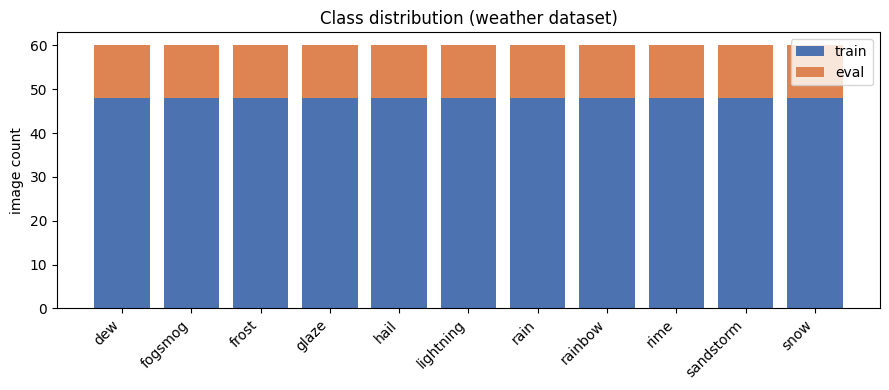

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(counts_df["label"], counts_df["train_count"], color="#4C72B0", label="train")
ax.bar(counts_df["label"], counts_df["eval_count"], bottom=counts_df["train_count"], color="#DD8452", label="eval")
ax.set_ylabel("image count")
ax.set_title("Class distribution (weather dataset)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

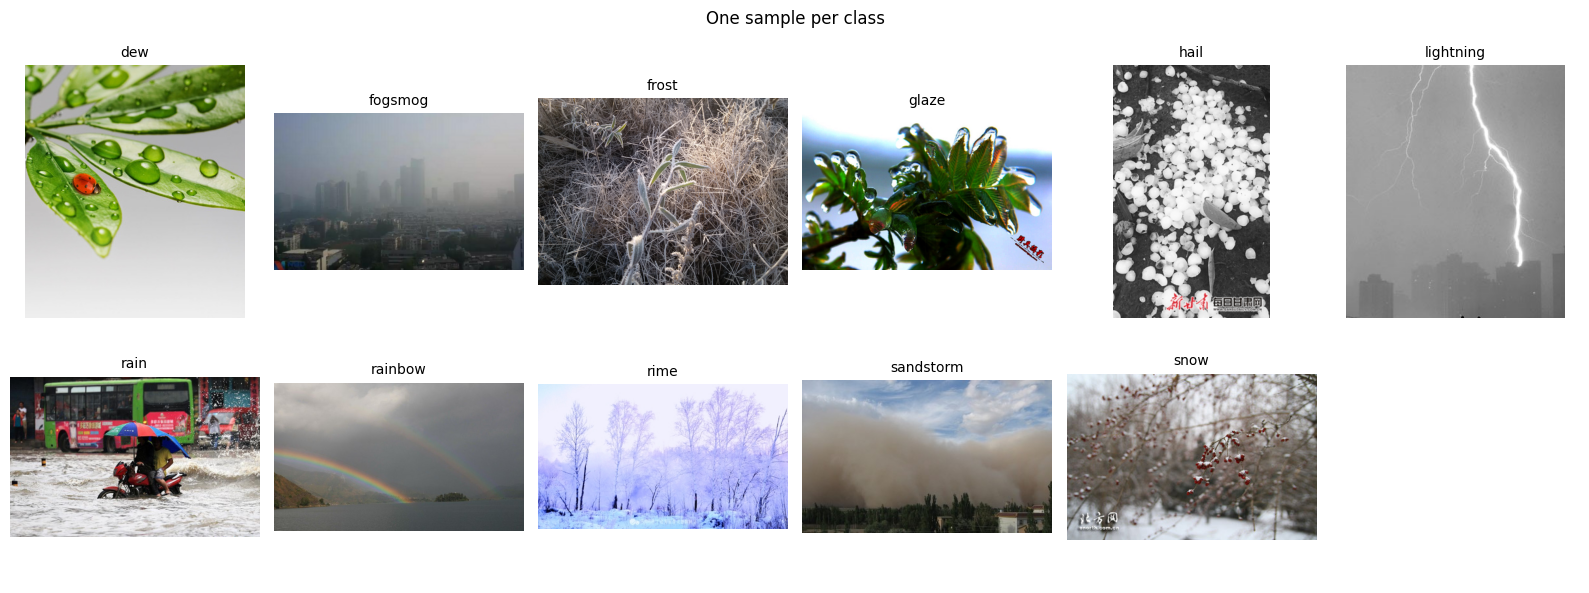

In [5]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
random.seed(0)
for ax, cls in zip(axes.flat, label_names):
    paths = glob.glob(os.path.join(DATA_DIR, cls, "*"))
    img = Image.open(random.choice(paths)).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
for ax in axes.flat[len(label_names):]:
    ax.axis("off")
plt.suptitle("One sample per class")
plt.tight_layout()
plt.show()

## Load the pretrained ViT and swap its head

`google/vit-base-patch16-224` was trained on 1000 ImageNet classes. We load it with
`num_labels=11` so Transformers replaces the final classification layer with a fresh,
randomly-initialized 11-way head (the mismatched-size original head is dropped).

In [6]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_NAME = "google/vit-base-patch16-224"

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}

base_model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
print(base_model.classifier)

Using device: mps


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([11]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([11, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Linear(in_features=768, out_features=11, bias=True)


## Attach LoRA adapters

We freeze the backbone and inject small trainable low-rank matrices into the attention
`query`/`value` projections (`r=8`). The new classifier head is also kept fully trainable
via `modules_to_save`, since it has no pretrained knowledge to preserve.

In [7]:
from peft import LoraConfig, get_peft_model

full_params = sum(p.numel() for p in base_model.parameters())

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["classifier"],
)
model = get_peft_model(base_model, lora_config).to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = full_params - trainable_params

print(f"Total params:     {full_params:,}")
print(f"Trainable params: {trainable_params:,} ({100*trainable_params/full_params:.2f}%)")
print(f"Frozen params:    {frozen_params:,}")

Total params:     85,807,115
Trainable params: 303,371 (0.35%)
Frozen params:    85,503,744


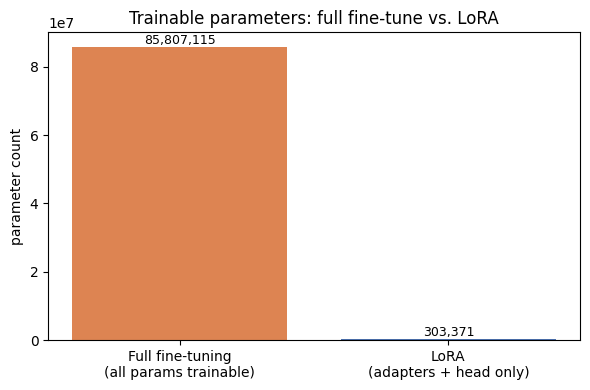

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Full fine-tuning\n(all params trainable)", "LoRA\n(adapters + head only)"],
       [full_params, trainable_params],
       color=["#DD8452", "#4C72B0"])
ax.set_ylabel("parameter count")
ax.set_title("Trainable parameters: full fine-tune vs. LoRA")
for i, v in enumerate([full_params, trainable_params]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Preprocess + train

We wrap each image with the ViT processor (resize/normalize) on the fly, then fine-tune
with Hugging Face's `Trainer`. Only the LoRA adapters + classifier head receive gradients.

In [9]:
def transform(batch):
    images = [img.convert("RGB") for img in batch["image"]]
    inputs = processor(images=images, return_tensors="pt")
    inputs["labels"] = batch["label"]
    return inputs

train_ds.set_transform(transform)
eval_ds.set_transform(transform)

def collate_fn(batch):
    pixel_values = torch.stack([torch.as_tensor(b["pixel_values"]) for b in batch])
    labels = torch.tensor([b["labels"] for b in batch])
    return {"pixel_values": pixel_values, "labels": labels}

print("Transforms attached.")

Transforms attached.


## Track the run with MLflow

Transformers' `Trainer` has a built-in MLflow integration — passing `report_to=["mlflow"]`
auto-logs hyperparameters, per-step training loss, and per-epoch eval metrics to whatever
run is active. We start an explicit run so we can also log the LoRA config and our own
artifacts (confusion matrix, sample predictions) into the same run.

In [10]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("vit-weather-lora")

mlflow_run = mlflow.start_run(run_name="vit-b16-lora-r8-weather")
mlflow.log_params({
    "model_name": MODEL_NAME,
    "num_labels": len(label_names),
    "lora_r": lora_config.r,
    "lora_alpha": lora_config.lora_alpha,
    "lora_target_modules": ",".join(lora_config.target_modules),
    "lora_dropout": lora_config.lora_dropout,
    "trainable_params": trainable_params,
    "total_params": full_params,
    "trainable_pct": round(100 * trainable_params / full_params, 4),
    "train_size": len(train_ds),
    "eval_size": len(eval_ds),
    "device": device,
})
print("MLflow run:", mlflow_run.info.run_id)

2026/07/25 19:44:09 INFO mlflow.tracking.fluent: Experiment with name 'vit-weather-lora' does not exist. Creating a new experiment.


MLflow run: 933c660a7e5d4a4bb1deb6492aa69ec1


In [11]:
import numpy as np
from transformers import TrainingArguments, Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": (preds == labels).mean()}

args = TrainingArguments(
    output_dir="./vit-weather-lora",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=6,
    learning_rate=5e-4,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=5,
    remove_unused_columns=False,
    report_to=["mlflow"],
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()

/Users/enkay/Documents/Claude/hf-cv-demo/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.938200,0.777363,0.840909
2,0.417700,0.443705,0.871212
3,0.229600,0.331688,0.901515
4,0.126600,0.331795,0.893939
5,0.075300,0.298280,0.909091
6,0.026000,0.297901,0.901515


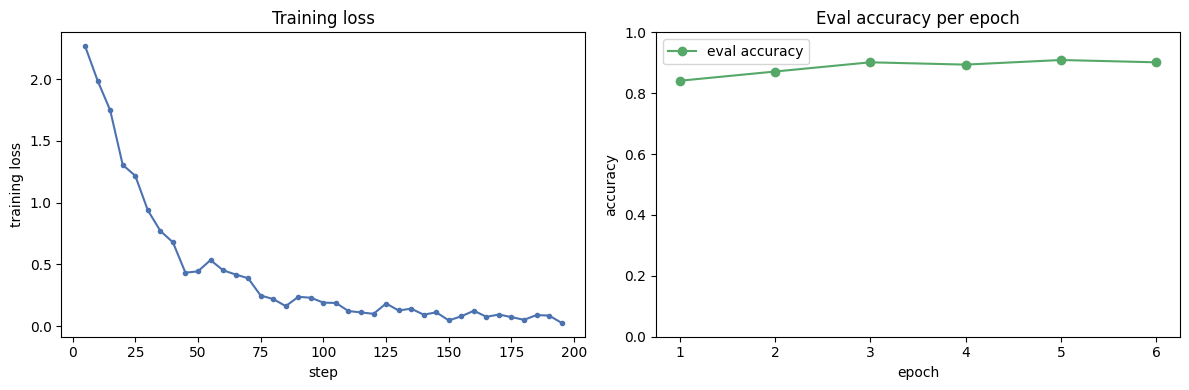

In [12]:
history = pd.DataFrame(trainer.state.log_history)
train_hist = history[history["loss"].notna()][["step", "loss"]]
eval_hist = history[history["eval_loss"].notna()][["epoch", "eval_loss", "eval_accuracy"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_hist["step"], train_hist["loss"], color="#4C72B0", marker="o", markersize=3)
axes[0].set_xlabel("step")
axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss")

axes[1].plot(eval_hist["epoch"], eval_hist["eval_accuracy"], color="#55A868", marker="o", label="eval accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1)
axes[1].set_title("Eval accuracy per epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluate: confusion matrix + sample predictions

/Users/enkay/Documents/Claude/hf-cv-demo/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


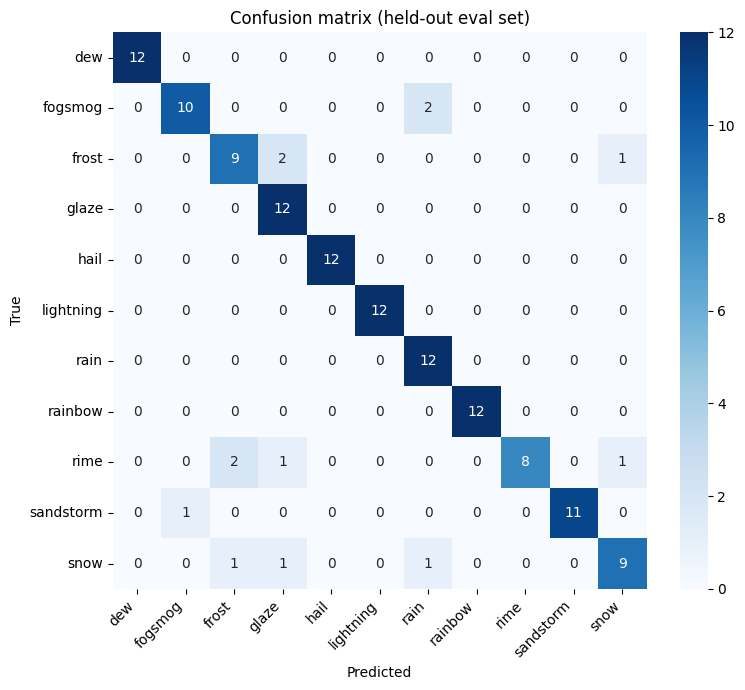

              precision    recall  f1-score   support

         dew       1.00      1.00      1.00        12
     fogsmog       0.91      0.83      0.87        12
       frost       0.75      0.75      0.75        12
       glaze       0.75      1.00      0.86        12
        hail       1.00      1.00      1.00        12
   lightning       1.00      1.00      1.00        12
        rain       0.80      1.00      0.89        12
     rainbow       1.00      1.00      1.00        12
        rime       1.00      0.67      0.80        12
   sandstorm       1.00      0.92      0.96        12
        snow       0.82      0.75      0.78        12

    accuracy                           0.90       132
   macro avg       0.91      0.90      0.90       132
weighted avg       0.91      0.90      0.90       132



In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

preds_output = trainer.predict(eval_ds)
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=-1)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (held-out eval set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
print(classification_report(y_true, y_pred, target_names=label_names))

mlflow.log_figure(fig, "confusion_matrix.png")
mlflow.log_metric("final_eval_accuracy", report["accuracy"])
for cls in label_names:
    mlflow.log_metric(f"f1_{cls}", report[cls]["f1-score"])

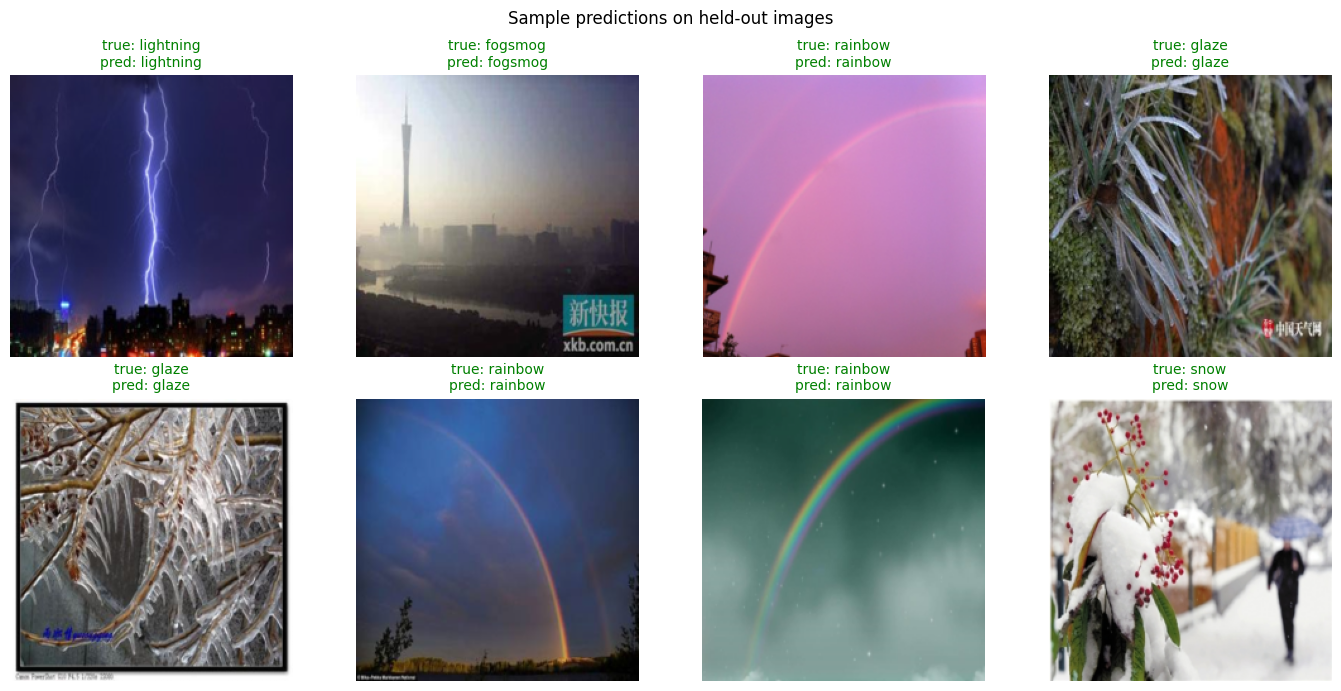

MLflow run closed. View with: mlflow ui --backend-store-uri file:./mlruns


In [14]:
random.seed(1)
sample_idxs = random.sample(range(len(eval_ds)), 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, sample_idxs):
    example = eval_ds[idx]
    true_label = label_names[y_true[idx]]
    pred_label = label_names[y_pred[idx]]
    img_tensor = example["pixel_values"]
    img = (np.array(img_tensor).transpose(1, 2, 0) * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img)
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"true: {true_label}\npred: {pred_label}", color=color, fontsize=10)
    ax.axis("off")
plt.suptitle("Sample predictions on held-out images")
plt.tight_layout()
plt.show()

mlflow.log_figure(fig, "sample_predictions.png")
mlflow.end_run()
print("MLflow run closed. View with: mlflow ui --backend-store-uri file:./mlruns")